In [1]:
"""
Fragment 1 — Data Loading with Dynamic Per-Class Augmentation
==============================================================
VGG19 Mould/Fruit Multiclass Classification Pipeline

- Discovers all classes automatically from train folder
- Augments each class up to MAX_TOTAL images then stops
- Saves augmented images to shared augmented folder
- Builds train and validation generators for model training
- Brightness augmentation excluded
- Test data not loaded here
"""

import os
import numpy as np
from pathlib import Path
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array,
)

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies\Mould Studies Multiclass"
TRAIN_DIR  = os.path.join(DATA_DIR, "train")
VALID_DIR  = os.path.join(DATA_DIR, "val")
AUG_DIR    = os.path.join(DATA_DIR, "augmented")   # shared with MobileNetV2

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
MAX_TOTAL   = 710

# ── Safety Guards ─────────────────────────────────────────────────────────────

assert "train" in TRAIN_DIR.lower(), \
    "TRAIN_DIR must point to the train folder only"
assert AUG_DIR != VALID_DIR, \
    "AUG_DIR must not point to val folder"
assert AUG_DIR != os.path.join(DATA_DIR, "test"), \
    "AUG_DIR must not point to test folder"

# ── Augmentation Parameters ───────────────────────────────────────────────────
# Brightness augmentation intentionally excluded

AUG_PARAMS = dict(
    rotation_range      = 20,
    width_shift_range   = 0.1,
    height_shift_range  = 0.1,
    horizontal_flip     = True,
    vertical_flip       = False,
    zoom_range          = 0.15,
    shear_range         = 0.1,
    channel_shift_range = 10,
    fill_mode           = "nearest",
)

# ── Step 1: Discover Classes ──────────────────────────────────────────────────

def discover_classes(train_dir: str) -> list:
    classes = sorted([
        d.name for d in Path(train_dir).iterdir()
        if d.is_dir()
    ])

    print("=" * 60)
    print("  Step 1 — Discovered Classes")
    print("=" * 60)
    for i, cls in enumerate(classes, 1):
        src_count = sum(
            1 for f in (Path(train_dir) / cls).iterdir()
            if f.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}
        )
        needed = max(0, MAX_TOTAL - src_count)
        print(f"  {i:>2}. {cls:<22} originals: {src_count:>4}   to generate: {needed:>4}")
    print("=" * 60)
    return classes

# ── Step 2: Augment and Save to Disk ─────────────────────────────────────────

def augment_and_save(train_dir: str, aug_dir: str, classes: list,
                     aug_params: dict) -> None:
    """
    For each class:
      - Copies all originals to the augmented folder
      - Generates augmented images one by one until MAX_TOTAL is reached
      - Stops immediately once the cap is hit
      - Skips classes already at or above MAX_TOTAL
      - Skips images already present in augmented folder
    """
    aug_gen  = ImageDataGenerator(**aug_params)
    IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

    print("\n" + "=" * 65)
    print("  Step 2 — Augmenting & Saving Images to Disk")
    print("=" * 65)
    print(f"  Source      : {train_dir}")
    print(f"  Destination : {aug_dir}")
    print(f"  Max total   : {MAX_TOTAL} images per class")
    print(f"  Brightness  : excluded")
    print("=" * 65)

    total_original  = 0
    total_augmented = 0

    for cls in classes:
        src_cls_dir = Path(train_dir) / cls
        dst_cls_dir = Path(aug_dir)   / cls
        dst_cls_dir.mkdir(parents=True, exist_ok=True)

        # Collect originals only — never re-augment previously generated images
        image_files = [
            f for f in src_cls_dir.iterdir()
            if f.suffix.lower() in IMG_EXTS
            and "_aug_" not in f.stem
        ]

        # ── Copy originals to augmented folder if not already there ──
        for img_path in image_files:
            dst = dst_cls_dir / img_path.name
            if not dst.exists():
                img = load_img(img_path, target_size=IMG_SIZE)
                img.save(dst)

        cls_original  = len(image_files)
        cls_aug_count = 0

        # Count what already exists in augmented folder
        already_in_aug = sum(
            1 for f in dst_cls_dir.iterdir()
            if f.suffix.lower() in IMG_EXTS
        )

        if already_in_aug >= MAX_TOTAL:
            print(f"  {cls:<22} | Already at {already_in_aug} images "
                  f"— skipping augmentation")
            total_original += cls_original
            continue

        needed = MAX_TOTAL - already_in_aug

        if needed <= 0:
            print(f"  {cls:<22} | Original: {cls_original:>4}  "
                  f"Augmented: {cls_aug_count:>4}  "
                  f"Total: {cls_original:>4}  (no aug needed)")
            total_original += cls_original
            continue

        # ── Generate augmented images until cap is reached ──
        aug_counter = 0

        while cls_aug_count < needed:
            img_path    = image_files[aug_counter % len(image_files)]
            aug_counter += 1

            img = load_img(img_path, target_size=IMG_SIZE)
            arr = np.expand_dims(img_to_array(img), axis=0)

            aug_iter = aug_gen.flow(
                arr,
                batch_size  = 1,
                save_to_dir = str(dst_cls_dir),
                save_prefix = f"aug_{img_path.stem}_{aug_counter:04d}",
                save_format = "jpg",
            )
            next(aug_iter)
            cls_aug_count += 1

        total_original  += cls_original
        total_augmented += cls_aug_count

        print(f"  {cls:<22} | Original: {cls_original:>4}  "
              f"Augmented: {cls_aug_count:>4}  "
              f"Total: {cls_original + cls_aug_count:>4}")

    print("\n" + "=" * 65)
    print(f"  {'TOTAL':<22} | Original: {total_original:>4}  "
          f"Augmented: {total_augmented:>4}  "
          f"Total: {total_original + total_augmented:>4}")
    print("=" * 65)
    print(f"\n  ✓ Augmented images saved to: {aug_dir}\n")

# ── Step 3: Build Generators ──────────────────────────────────────────────────

def build_generators(aug_dir: str, valid_dir: str):
    """
    Builds train generator from shared augmented folder (rescale only).
    Builds validation generator from val folder (rescale only).
    No augmentation applied at generator level.
    Test data is not loaded here.
    """

    train_datagen   = ImageDataGenerator(rescale=1.0 / 255)
    train_generator = train_datagen.flow_from_directory(
        aug_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = True,
    )

    valid_datagen   = ImageDataGenerator(rescale=1.0 / 255)
    valid_generator = valid_datagen.flow_from_directory(
        valid_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = False,
    )

    print("\n" + "=" * 60)
    print("  Step 3 — Data Generators Ready")
    print("=" * 60)
    print(f"  Train source  : augmented/   (shared)")
    print(f"  Valid source  : val/")
    print(f"  Test source   : not loaded here")
    print(f"  Train samples : {train_generator.samples}")
    print(f"  Valid samples : {valid_generator.samples}")
    print(f"  Classes       : {list(train_generator.class_indices.keys())}")
    print(f"  Image size    : {IMG_SIZE}")
    print(f"  Batch size    : {BATCH_SIZE}")
    print("=" * 60)

    return train_generator, valid_generator

# ── Run Fragment 1 ────────────────────────────────────────────────────────────

classes = discover_classes(TRAIN_DIR)
augment_and_save(TRAIN_DIR, AUG_DIR, classes, AUG_PARAMS)
train_generator, valid_generator = build_generators(AUG_DIR, VALID_DIR)

print("\n  ✓ Fragment 1 complete. train_generator and valid_generator are ready.")
print("     Proceed to Fragment 2 — VGG19 Model Building.\n")


  Step 1 — Discovered Classes
   1. Blackberry             originals:  117   to generate:  593
   2. Blueberry              originals:  117   to generate:  593
   3. Carrots                originals:  235   to generate:  475
   4. Cheese                 originals:  142   to generate:  568
   5. Cream Cheese           originals:  233   to generate:  477
   6. Mixed Bread            originals:  168   to generate:  542
   7. Onion                  originals:  479   to generate:  231
   8. Orange                 originals:  329   to generate:  381
   9. Raspberry              originals:  117   to generate:  593
  10. Toast                  originals:  478   to generate:  232
  11. Tomatoes               originals:  604   to generate:  106

  Step 2 — Augmenting & Saving Images to Disk
  Source      : D:\Mold Studies\Mould Studies Multiclass\train
  Destination : D:\Mold Studies\Mould Studies Multiclass\augmented
  Max total   : 710 images per class
  Brightness  : excluded
  Blackberry   

In [ ]:
"""
Fragment 2 — VGG19 Model Building with Transfer Learning
=========================================================
- Loads VGG19 with ImageNet weights
- Accepts learning rate, dropout rate and unfreeze depth as inputs
- Freezes base layers except last N unfrozen layers
- Adds custom classification head
- Compiled and ready for training in Fragment 3
"""

import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    Flatten,
)
from tensorflow.keras.optimizers import Adam

# ── Configuration ─────────────────────────────────────────────────────────────

IMG_SIZE    = (224, 224)
IMG_SHAPE   = IMG_SIZE + (3,)
NUM_CLASSES = len(train_generator.class_indices)
CLASS_NAMES = list(train_generator.class_indices.keys())

# ── Default values ────────────────────────────────────────────────────────────

DEFAULT_LEARNING_RATE   = 0.000976
DEFAULT_DROPOUT_RATE    = 0.6     # VGG19 benefits from higher dropout
DEFAULT_UNFREEZE_LAYERS = 2
EPOCHS                  = 25

# ── Step 1: Model Builder ─────────────────────────────────────────────────────

def build_vgg19(learning_rate, dropout_rate, unfreeze_layers, epochs=EPOCHS):
    """
    Builds and compiles VGG19 with a custom classification head.

    Parameters
    ----------
    learning_rate   : float — Adam optimizer learning rate
                              Recommended range : 1e-5 to 1e-3 (log scale)

    dropout_rate    : float — dropout applied in classification head
                              Recommended range : 0.3 to 0.6
                              VGG19 is a large model and benefits from
                              stronger regularisation than MobileNetV2

    unfreeze_layers : int   — number of base layers unfrozen from the top
                              Recommended range : 0 to 8
                              VGG19 has fewer but heavier blocks than
                              MobileNetV2 so unfreeze conservatively
                              0  = fully frozen, feature extraction only
                              4  = unfreeze last conv block (block5)
                              8  = unfreeze last two conv blocks

    epochs          : int   — number of training epochs
                              default : 25
    """

    # ── Load VGG19 with ImageNet weights ──
    base_model = VGG19(
        input_shape = IMG_SHAPE,
        include_top = False,        # remove ImageNet classifier
        weights     = "imagenet"    # load ImageNet weights
    )

    # ── Freeze all base layers first ──
    base_model.trainable = False

    # ── Unfreeze last N layers (skip BatchNorm layers) ──
    # Note: VGG19 does not use BatchNorm in its base but
    # guard is kept for safety consistency
    if unfreeze_layers > 0:
        for layer in base_model.layers[-unfreeze_layers:]:
            if not isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = True

    # ── Classification head ──
    # VGG19 uses Flatten instead of GlobalAveragePooling2D
    # as it produces better results with VGG architecture
    x      = base_model.output
    x      = Flatten(name="flatten")(x)
    x      = BatchNormalization(name="head_batch_norm")(x)
    x      = Dense(512, activation="relu", name="dense_512")(x)
    x      = Dropout(dropout_rate, name="dropout_1")(x)
    x      = Dense(256, activation="relu", name="dense_256")(x)
    x      = Dropout(dropout_rate / 2, name="dropout_2")(x)
    output = Dense(NUM_CLASSES, activation="softmax", name="output")(x)

    # ── Assemble model ──
    model = Model(inputs=base_model.input, outputs=output)

    # ── Compile ──
    model.compile(
        optimizer = Adam(learning_rate=learning_rate),
        loss      = "categorical_crossentropy",
        metrics   = ["accuracy"]
    )

    return model, base_model

# ── Step 2: Build default model and print summary ─────────────────────────────

model, base_model = build_vgg19(
    learning_rate   = DEFAULT_LEARNING_RATE,
    dropout_rate    = DEFAULT_DROPOUT_RATE,
    unfreeze_layers = DEFAULT_UNFREEZE_LAYERS
)

# ── Count parameters ──
total_params     = model.count_params()
trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen_params    = sum(tf.size(w).numpy() for w in model.non_trainable_weights)

# ── Count unfrozen base layers ──
unfrozen_base = sum(
    1 for l in model.layers
    if l.trainable
    and l.name not in
    ["flatten", "head_batch_norm",
     "dense_512", "dropout_1",
     "dense_256", "dropout_2", "output"]
)

print("=" * 60)
print("  Fragment 2 — VGG19 Transfer Learning")
print("=" * 60)

print("\n  ── Inputs ──────────────────────────────────────────")
print(f"  Learning rate    : {DEFAULT_LEARNING_RATE}")
print(f"  Dropout rate     : {DEFAULT_DROPOUT_RATE}")
print(f"  Unfreeze layers  : {DEFAULT_UNFREEZE_LAYERS}")
print(f"  Epochs           : {EPOCHS}")

print("\n  ── Base Model ──────────────────────────────────────")
print(f"  Architecture     : VGG19")
print(f"  Weights          : ImageNet ✓")
print(f"  Input shape      : {IMG_SHAPE}")
print(f"  Total base layers: {len(base_model.layers)}")
print(f"  Unfrozen layers  : {unfrozen_base}")

print("\n  ── Classification Head ─────────────────────────────")
print(f"  Flatten")
print(f"  BatchNormalization")
print(f"  Dense(512, relu)")
print(f"  Dropout({DEFAULT_DROPOUT_RATE})")
print(f"  Dense(256, relu)")
print(f"  Dropout({DEFAULT_DROPOUT_RATE / 2})")
print(f"  Dense({NUM_CLASSES}, softmax)  ← {NUM_CLASSES} classes")
print(f"  Classes          : {CLASS_NAMES}")

print("\n  ── Parameters ──────────────────────────────────────")
print(f"  Total params     : {total_params:,}")
print(f"  Trainable        : {trainable_params:,}")
print(f"  Frozen           : {frozen_params:,}")

print("\n  ── Recommended Search Space ────────────────────────")
print(f"  learning_rate    : 1e-5  → 1e-3  (log scale)")
print(f"  dropout_rate     : 0.3   → 0.6")
print(f"  unfreeze_layers  : 0     → 8")
print(f"  epochs           : {EPOCHS}")
print("=" * 60)

print("\n  ✓ Fragment 2 complete. build_vgg19() is ready.")
print("     Proceed to Fragment 3 — Callbacks & Training.\n")



  Fragment 2 — VGG19 Transfer Learning

  ── Inputs ──────────────────────────────────────────
  Learning rate    : 0.000976
  Dropout rate     : 0.6
  Unfreeze layers  : 2
  Epochs           : 25

  ── Base Model ──────────────────────────────────────
  Architecture     : VGG19
  Weights          : ImageNet ✓
  Input shape      : (224, 224, 3)
  Total base layers: 22
  Unfrozen layers  : 2

  ── Classification Head ─────────────────────────────
  Flatten
  BatchNormalization
  Dense(512, relu)
  Dropout(0.6)
  Dense(256, relu)
  Dropout(0.3)
  Dense(11, softmax)  ← 11 classes
  Classes          : ['Blackberry', 'Blueberry', 'Carrots', 'Cheese', 'Cream Cheese', 'Mixed Bread', 'Onion', 'Orange', 'Raspberry', 'Toast', 'Tomatoes']

  ── Parameters ──────────────────────────────────────
  Total params     : 33,104,459
  Trainable        : 15,389,707
  Frozen           : 17,714,752

  ── Recommended Search Space ────────────────────────
  learning_rate    : 1e-5  → 1e-3  (log scale)
  dro

In [3]:
"""
Fragment 3 — Callbacks & Model Training
========================================
VGG19 Mould/Fruit Multiclass Classification Pipeline

- Defines all callbacks:
    * ModelCheckpoint    — saves best model based on val_accuracy
    * EarlyStopping      — stops training if no improvement
    * ReduceLROnPlateau  — reduces LR when val_loss stalls
    * CSVLogger          — logs all metrics per epoch to CSV
- Trains VGG19 using parameters defined in Fragment 2
- Validates on val set only
- Stores history for Fragment 4 evaluation:
    * Accuracy, Loss curves
    * Sensitivity, Specificity, Recall, F1, AUC/ROC
    * Confusion Matrix
"""

import os
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger,
)

# ── Configuration ─────────────────────────────────────────────────────────────

SAVE_DIR     = r"D:\Mold Studies\Models"
MODEL_NAME   = "vgg19_mould_best.keras"
CSV_LOG_NAME = "vgg19_training_log.csv"

os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(SAVE_DIR, MODEL_NAME)
CSV_PATH   = os.path.join(SAVE_DIR, CSV_LOG_NAME)

# ── Callback Parameters ───────────────────────────────────────────────────────

# EarlyStopping
ES_PATIENCE   = 10       # stop after N epochs with no val_accuracy improvement
ES_MIN_DELTA  = 1e-4     # minimum change to count as improvement

# ReduceLROnPlateau
RLROP_FACTOR    = 0.5    # multiply LR by this on plateau
RLROP_PATIENCE  = 5      # epochs with no improvement before reducing LR
RLROP_MIN_LR    = 1e-7   # LR floor
RLROP_MIN_DELTA = 1e-4   # minimum change to count as improvement

# ── Step 1: Define Callbacks ──────────────────────────────────────────────────

checkpoint = ModelCheckpoint(
    filepath          = MODEL_PATH,
    monitor           = "val_accuracy",
    save_best_only    = True,
    save_weights_only = False,
    save_format       = "keras",
    mode              = "max",
    verbose           = 1,
)

early_stopping = EarlyStopping(
    monitor              = "val_accuracy",
    patience             = ES_PATIENCE,
    min_delta            = ES_MIN_DELTA,
    mode                 = "max",
    restore_best_weights = True,
    verbose              = 1,
)

reduce_lr = ReduceLROnPlateau(
    monitor   = "val_loss",
    factor    = RLROP_FACTOR,
    patience  = RLROP_PATIENCE,
    min_lr    = RLROP_MIN_LR,
    min_delta = RLROP_MIN_DELTA,
    mode      = "min",
    verbose   = 1,
)

csv_logger = CSVLogger(
    filename  = CSV_PATH,
    separator = ",",
    append    = False,
)

callbacks = [checkpoint, early_stopping, reduce_lr, csv_logger]

print("=" * 60)
print("  Step 1 — Callbacks Configured")
print("=" * 60)
print(f"  ModelCheckpoint  : best val_accuracy → {MODEL_PATH}")
print(f"  EarlyStopping    : patience={ES_PATIENCE} epochs, "
      f"restores best weights")
print(f"  ReduceLROnPlateau: factor={RLROP_FACTOR} after "
      f"{RLROP_PATIENCE} stale epochs, floor={RLROP_MIN_LR}")
print(f"  CSVLogger        : epoch log → {CSV_PATH}")
print("=" * 60)

# ── Step 2: Training Configuration ───────────────────────────────────────────

print("\n" + "=" * 60)
print("  Step 2 — Training Configuration")
print("=" * 60)
print(f"  Architecture     : VGG19")
print(f"  Train samples    : {train_generator.samples}")
print(f"  Valid samples    : {valid_generator.samples}")
print(f"  Test samples     : not touched here")
print(f"  Classes          : {NUM_CLASSES}")
print(f"  Epochs           : {EPOCHS}")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Learning rate    : {DEFAULT_LEARNING_RATE:.6f}")
print(f"  Dropout rate     : {DEFAULT_DROPOUT_RATE:.4f}")
print(f"  Unfreeze layers  : {DEFAULT_UNFREEZE_LAYERS}")
print("=" * 60 + "\n")

# ── Step 3: Build Final Model ─────────────────────────────────────────────────

model, base_model = build_vgg19(
    learning_rate   = DEFAULT_LEARNING_RATE,
    dropout_rate    = DEFAULT_DROPOUT_RATE,
    unfreeze_layers = DEFAULT_UNFREEZE_LAYERS,
    epochs          = EPOCHS,
)

# ── Step 4: Train ─────────────────────────────────────────────────────────────

history = model.fit(
    train_generator,
    epochs           = EPOCHS,
    validation_data  = valid_generator,
    callbacks        = callbacks,
    steps_per_epoch  = train_generator.samples  // BATCH_SIZE,
    validation_steps = valid_generator.samples  // BATCH_SIZE,
)

# ── Step 5: Force Save in .keras Format ──────────────────────────────────────

model.save(MODEL_PATH)
print(f"\n  ✓ Model explicitly saved in .keras format → {MODEL_PATH}")

# ── Step 6: Training Summary ──────────────────────────────────────────────────

best_val_acc  = max(history.history["val_accuracy"])
best_val_loss = min(history.history["val_loss"])
epochs_run    = len(history.history["accuracy"])
best_epoch    = history.history["val_accuracy"].index(best_val_acc) + 1

print("\n" + "=" * 60)
print("  Step 6 — Training Complete")
print("=" * 60)
print(f"  Architecture     : VGG19")
print(f"  Epochs run       : {epochs_run} / {EPOCHS}")
print(f"  Best epoch       : {best_epoch}")
print(f"  Best val accuracy: {best_val_acc:.4f}  ({best_val_acc * 100:.2f}%)")
print(f"  Best val loss    : {best_val_loss:.4f}")
print(f"  Best model saved : {MODEL_PATH}")
print(f"  Training log     : {CSV_PATH}")
print("=" * 60)

print("\n  ── Metrics available for Fragment 4 evaluation ─────")
print("  ✓ Accuracy        — per epoch (train + val)")
print("  ✓ Loss            — per epoch (train + val)")
print("  ✓ Sensitivity     — will be computed from confusion matrix")
print("  ✓ Specificity     — will be computed from confusion matrix")
print("  ✓ Recall          — will be computed from confusion matrix")
print("  ✓ F1 Score        — will be computed from confusion matrix")
print("  ✓ AUC / ROC       — will be computed per class (one-vs-rest)")
print("  ✓ Confusion Matrix — full 11-class matrix")
print("=" * 60)

print("\n  ✓ Fragment 3 complete. history and model are ready.")
print("     Proceed to Fragment 3b — Multi-Run Training.\n")

  Step 1 — Callbacks Configured
  ModelCheckpoint  : best val_accuracy → D:\Mold Studies\Models\vgg19_mould_best.keras
  EarlyStopping    : patience=10 epochs, restores best weights
  ReduceLROnPlateau: factor=0.5 after 5 stale epochs, floor=1e-07
  CSVLogger        : epoch log → D:\Mold Studies\Models\vgg19_training_log.csv

  Step 2 — Training Configuration
  Architecture     : VGG19
  Train samples    : 8833
  Valid samples    : 644
  Test samples     : not touched here
  Classes          : 11
  Epochs           : 25
  Batch size       : 32
  Learning rate    : 0.000976
  Dropout rate     : 0.6000
  Unfreeze layers  : 2

Epoch 1/25


276/276 [==============================] - ETA: 0s - loss: 1.2768 - accuracy: 0.7754
Epoch 1: val_accuracy improved from -inf to 0.84844, saving model to D:\Mold Studies\Models\vgg19_mould_best.keras
276/276 [==============================] - 675s 2s/step - loss: 1.2768 - accuracy: 0.7754 - val_loss: 0.5102 - val_accuracy: 0.8484 - lr: 9.7600e-04
Epoch 

In [4]:
"""
Fragment 3b — Multi-Run Training (VGG19)
=========================================
VGG19 Mould/Fruit Multiclass Classification Pipeline

Runs 4 additional independent training loops (Runs 2–5).
Run 1 was completed in Fragment 3 and its model is already saved.
Each run starts from fresh ImageNet weights with randomly
reinitialised classification head.

OUTPUT: 5 models saved to disk for statistical analysis
    vgg19_run1_best.keras   (copied from Fragment 3)
    vgg19_run2_best.keras
    vgg19_run3_best.keras
    vgg19_run4_best.keras
    vgg19_run5_best.keras

DATA BOUNDARIES — unchanged from Fragment 3:
    Training   : train_generator  (augmented folder)
    Validation : valid_generator  (val folder)
    Test       : NOT TOUCHED — Fragment 4 only
"""

import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger,
)

# ── Configuration ─────────────────────────────────────────────────────────────

SAVE_DIR   = r"D:\Mold Studies\Models"
TOTAL_RUNS = 5

os.makedirs(SAVE_DIR, exist_ok=True)

# ── Step 1: Copy Fragment 3 model → Run 1 ────────────────────────────────────

src = os.path.join(SAVE_DIR, "vgg19_mould_best.keras")
dst = os.path.join(SAVE_DIR, "vgg19_run1_best.keras")

if os.path.exists(src) and not os.path.exists(dst):
    shutil.copy2(src, dst)
    print(f"  Copied  : vgg19_mould_best.keras → vgg19_run1_best.keras")
elif os.path.exists(dst):
    print(f"  Already exists : vgg19_run1_best.keras — skipping copy")
else:
    print(f"  WARNING : vgg19_mould_best.keras not found")
    print(f"            Ensure Fragment 3 completed successfully before continuing")

# ── Step 2: Collect Run 1 results from Fragment 3 ────────────────────────────

all_run_results = [
    {
        "run"          : 1,
        "best_val_acc" : best_val_acc,
        "best_val_loss": best_val_loss,
        "best_epoch"   : best_epoch,
        "checkpoint"   : "vgg19_run1_best.keras"
    }
]

print(f"\n  Run 1 loaded from Fragment 3")
print(f"    Architecture      : VGG19")
print(f"    Best val accuracy : {best_val_acc:.4f}")
print(f"    Best val loss     : {best_val_loss:.4f}")
print(f"    Best epoch        : {best_epoch}")

# ── Step 3: Runs 2–5 ──────────────────────────────────────────────────────────

print(f"\n{'='*60}")
print(f"  MULTI-RUN TRAINING — Runs 2 to {TOTAL_RUNS}")
print(f"  Architecture : VGG19")
print(f"  Each run     : fresh ImageNet weights, random head init")
print(f"  Epochs       : {EPOCHS}")
print(f"  LR           : {DEFAULT_LEARNING_RATE}")
print(f"  Dropout      : {DEFAULT_DROPOUT_RATE}")
print(f"  Unfreeze     : {DEFAULT_UNFREEZE_LAYERS} layers")
print(f"{'='*60}")

for run_idx in range(2, TOTAL_RUNS + 1):

    print(f"\n{'='*60}")
    print(f"  RUN {run_idx} / {TOTAL_RUNS}  —  VGG19")
    print(f"{'='*60}\n")

    ckpt_path = os.path.join(SAVE_DIR, f"vgg19_run{run_idx}_best.keras")
    csv_path  = os.path.join(SAVE_DIR, f"vgg19_run{run_idx}_log.csv")

    # ── Fresh model — new random head, ImageNet backbone ──────────────────────
    run_model, _ = build_vgg19(
        learning_rate   = DEFAULT_LEARNING_RATE,
        dropout_rate    = DEFAULT_DROPOUT_RATE,
        unfreeze_layers = DEFAULT_UNFREEZE_LAYERS,
        epochs          = EPOCHS,
    )

    # ── Run-specific callbacks ─────────────────────────────────────────────────
    run_callbacks = [
        ModelCheckpoint(
            filepath          = ckpt_path,
            monitor           = "val_accuracy",
            save_best_only    = True,
            save_weights_only = False,
            save_format       = "keras",
            mode              = "max",
            verbose           = 1,
        ),
        EarlyStopping(
            monitor              = "val_accuracy",
            patience             = ES_PATIENCE,
            min_delta            = ES_MIN_DELTA,
            mode                 = "max",
            restore_best_weights = True,
            verbose              = 1,
        ),
        ReduceLROnPlateau(
            monitor   = "val_loss",
            factor    = RLROP_FACTOR,
            patience  = RLROP_PATIENCE,
            min_lr    = RLROP_MIN_LR,
            min_delta = RLROP_MIN_DELTA,
            mode      = "min",
            verbose   = 1,
        ),
        CSVLogger(
            filename  = csv_path,
            separator = ",",
            append    = False,
        ),
    ]

    # ── Train ──────────────────────────────────────────────────────────────────
    run_history = run_model.fit(
        train_generator,
        validation_data  = valid_generator,
        epochs           = EPOCHS,
        callbacks        = run_callbacks,
        steps_per_epoch  = train_generator.samples // BATCH_SIZE,
        validation_steps = valid_generator.samples // BATCH_SIZE,
    )

    # ── Extract best metrics ───────────────────────────────────────────────────
    run_best_val_acc  = max(run_history.history["val_accuracy"])
    run_best_val_loss = min(run_history.history["val_loss"])
    run_best_epoch    = run_history.history["val_accuracy"].index(run_best_val_acc) + 1
    run_epochs_run    = len(run_history.history["accuracy"])

    # ── Force save in .keras format ───────────────────────────────────────────
    run_model.save(ckpt_path)

    all_run_results.append({
        "run"          : run_idx,
        "best_val_acc" : run_best_val_acc,
        "best_val_loss": run_best_val_loss,
        "best_epoch"   : run_best_epoch,
        "checkpoint"   : f"vgg19_run{run_idx}_best.keras"
    })

    print(f"\n  Run {run_idx} complete")
    print(f"    Epochs run        : {run_epochs_run} / {EPOCHS}")
    print(f"    Best epoch        : {run_best_epoch}")
    print(f"    Best val accuracy : {run_best_val_acc:.4f}")
    print(f"    Best val loss     : {run_best_val_loss:.4f}")
    print(f"    Saved to          : {ckpt_path}")

# ── Step 4: Summary across all 5 runs ────────────────────────────────────────

val_accs   = [r["best_val_acc"]  for r in all_run_results]
val_losses = [r["best_val_loss"] for r in all_run_results]

print(f"\n{'='*60}")
print(f"  ALL RUNS COMPLETE — VGG19 Summary")
print(f"{'='*60}")
print(f"  {'Run':<6} {'Val Acc':>10} {'Val Loss':>10} "
      f"{'Best Epoch':>12} {'Checkpoint'}")
print(f"  {'─'*70}")

for r in all_run_results:
    print(f"  {r['run']:<6} {r['best_val_acc']:>10.4f} "
          f"{r['best_val_loss']:>10.4f} {r['best_epoch']:>12} "
          f"{r['checkpoint']}")

best_run = max(all_run_results, key=lambda x: x["best_val_acc"])

print(f"\n  {'─'*60}")
print(f"  Mean val accuracy  : {np.mean(val_accs):.4f}")
print(f"  Std  val accuracy  : {np.std(val_accs):.4f}")
print(f"  Mean val loss      : {np.mean(val_losses):.4f}")
print(f"  Std  val loss      : {np.std(val_losses):.4f}")
print(f"\n  Best single run    : Run {best_run['run']} "
      f"— Val Acc {best_run['best_val_acc']:.4f}")
print(f"{'='*60}")

# ── Step 5: Expose checkpoint list for Fragment 4 ────────────────────────────

ensemble_checkpoints = [
    os.path.join(SAVE_DIR, r["checkpoint"]) for r in all_run_results
]

print(f"\n  ✓ Fragment 3b complete.")
print(f"  ensemble_checkpoints = {ensemble_checkpoints}")
print(f"\n     Proceed to Fragment 4 — Evaluation & Metrics.\n")

  Already exists : vgg19_run1_best.keras — skipping copy

  Run 1 loaded from Fragment 3
    Architecture      : VGG19
    Best val accuracy : 0.9922
    Best val loss     : 0.0243
    Best epoch        : 20

  MULTI-RUN TRAINING — Runs 2 to 5
  Architecture : VGG19
  Each run     : fresh ImageNet weights, random head init
  Epochs       : 25
  LR           : 0.000976
  Dropout      : 0.6
  Unfreeze     : 2 layers

  RUN 2 / 5  —  VGG19

Epoch 1/25
276/276 [==============================] - ETA: 0s - loss: 1.2099 - accuracy: 0.7816
Epoch 1: val_accuracy improved from -inf to 0.93750, saving model to D:\Mold Studies\Models\vgg19_run2_best.keras
276/276 [==============================] - 437s 2s/step - loss: 1.2099 - accuracy: 0.7816 - val_loss: 0.2158 - val_accuracy: 0.9375 - lr: 9.7600e-04
Epoch 2/25
276/276 [==============================] - ETA: 0s - loss: 0.3207 - accuracy: 0.9228
Epoch 2: val_accuracy did not improve from 0.93750
276/276 [==============================] - 436s 2s/s

Found 658 images belonging to 11 classes.
  Step 1 — Test Generator Ready
  Architecture : VGG19
  Test samples : 658
  Classes      : ['Blackberry', 'Blueberry', 'Carrots', 'Cheese', 'Cream Cheese', 'Mixed Bread', 'Onion', 'Orange', 'Raspberry', 'Toast', 'Tomatoes']
  Source       : D:\Mold Studies\Mould Studies Multiclass\test

  Evaluating VGG19 Run 1 / 5
  Checkpoint : D:\Mold Studies\Models\vgg19_run1_best.keras
21/21 [==============================] - 26s 1s/step

  Architecture : VGG19
  Run          : 1
  Accuracy     : 0.9878
  Precision    : 0.9888
  Recall       : 0.9865
  Specificity  : 0.9987
  F1 Score     : 0.9875
  Mean AUC     : 0.9998


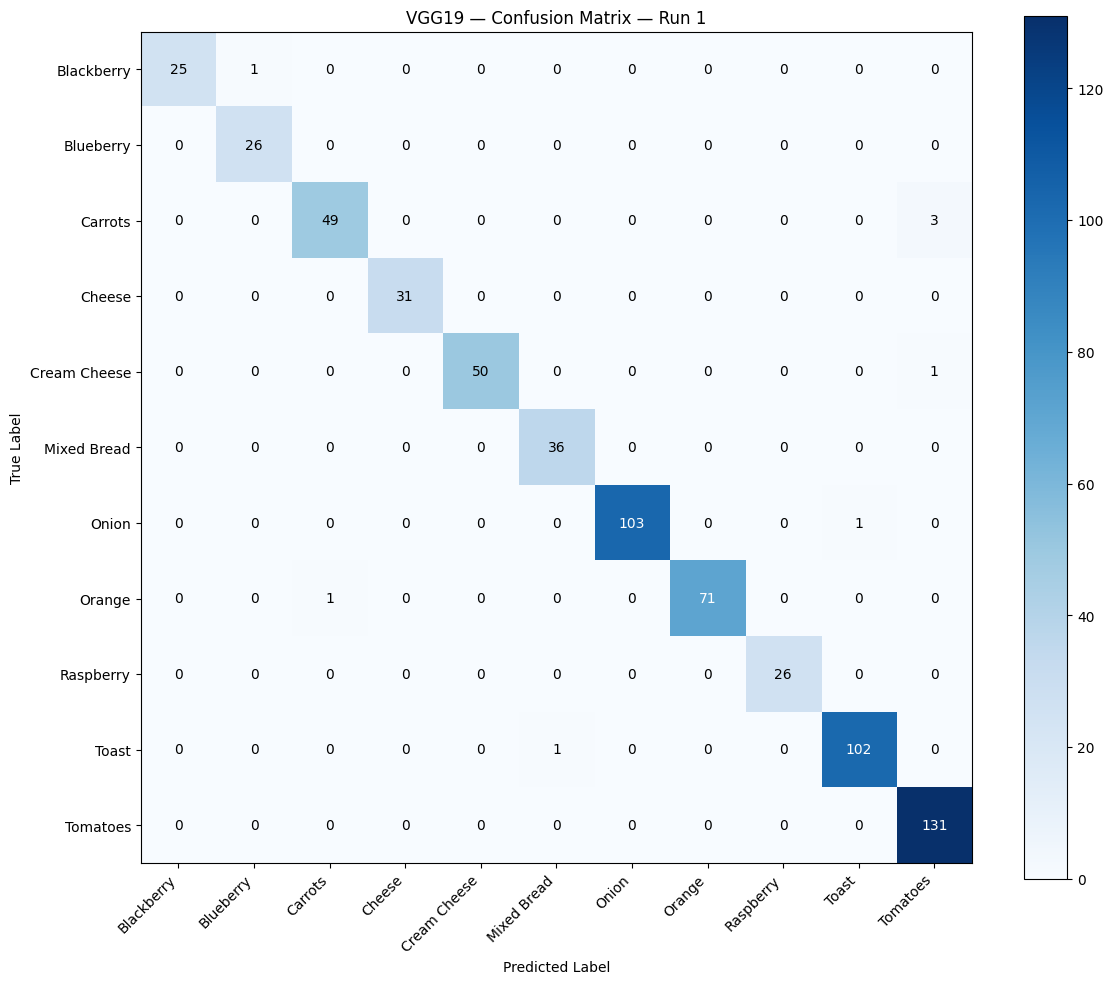

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_confusion_matrix_run1.png


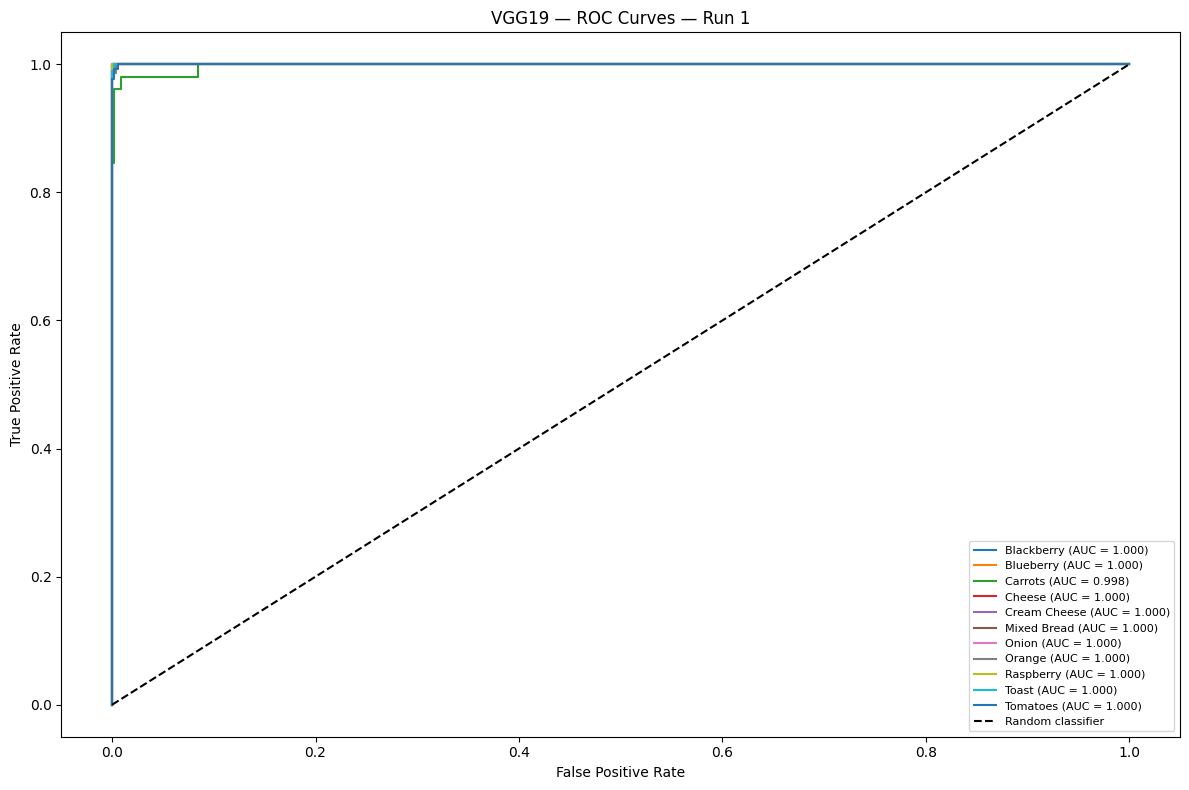

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_roc_curves_run1.png


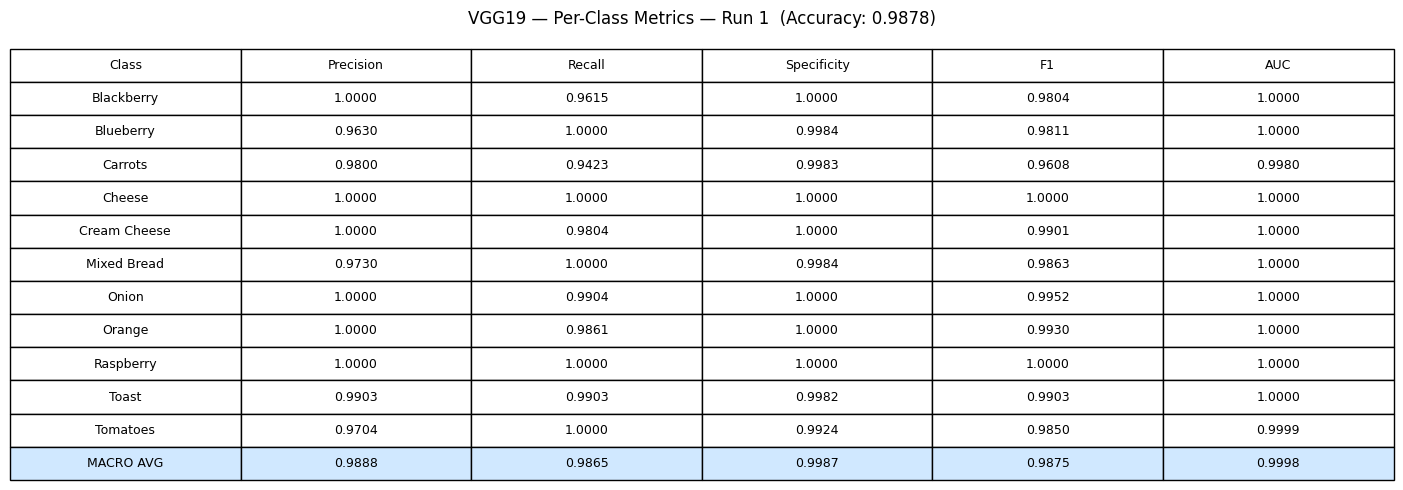

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_metrics_table_run1.png
  ⚠️  CSV log not found for Run 1: D:\Mold Studies\Models\vgg19_run1_log.csv

  Evaluating VGG19 Run 2 / 5
  Checkpoint : D:\Mold Studies\Models\vgg19_run2_best.keras
21/21 [==============================] - 27s 1s/step

  Architecture : VGG19
  Run          : 2
  Accuracy     : 0.9909
  Precision    : 0.9916
  Recall       : 0.9905
  Specificity  : 0.9990
  F1 Score     : 0.9909
  Mean AUC     : 0.9998


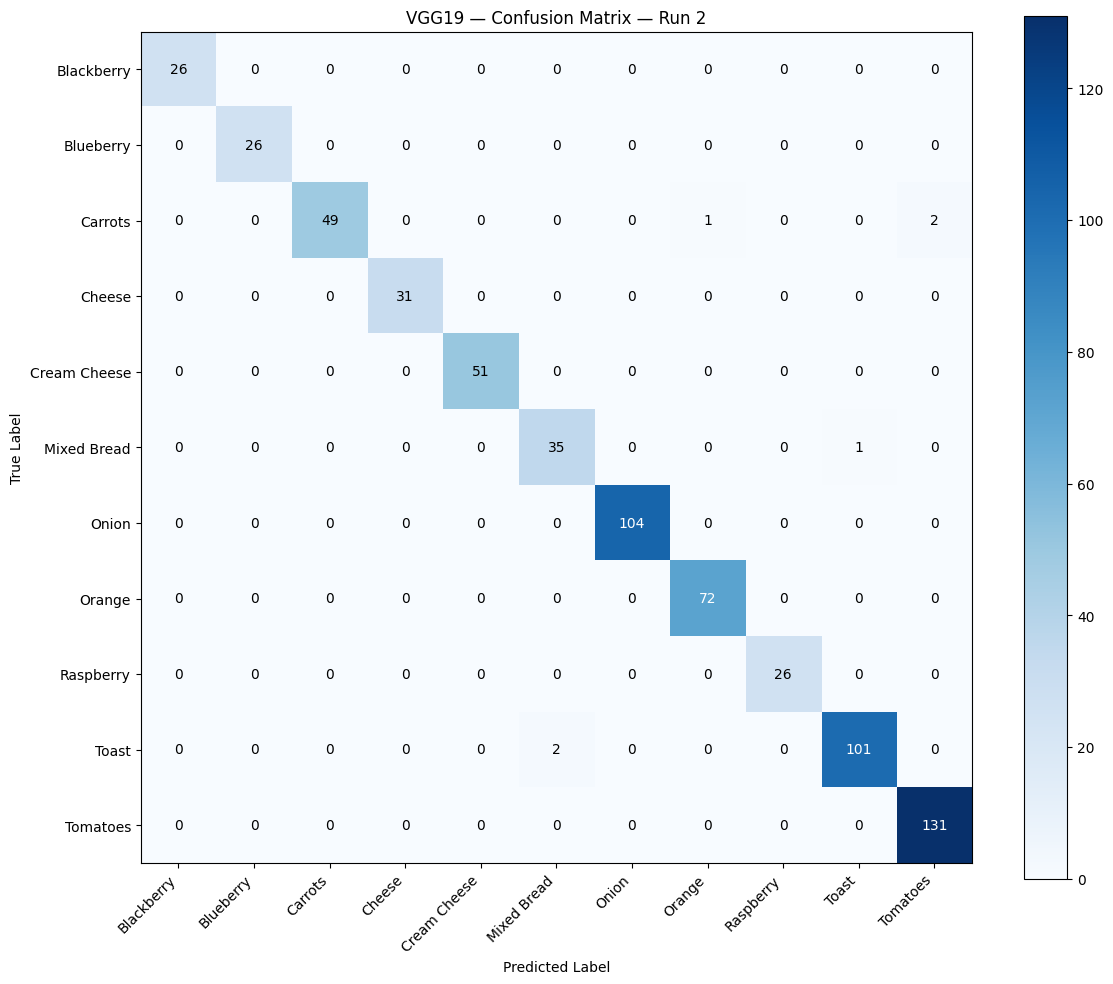

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_confusion_matrix_run2.png


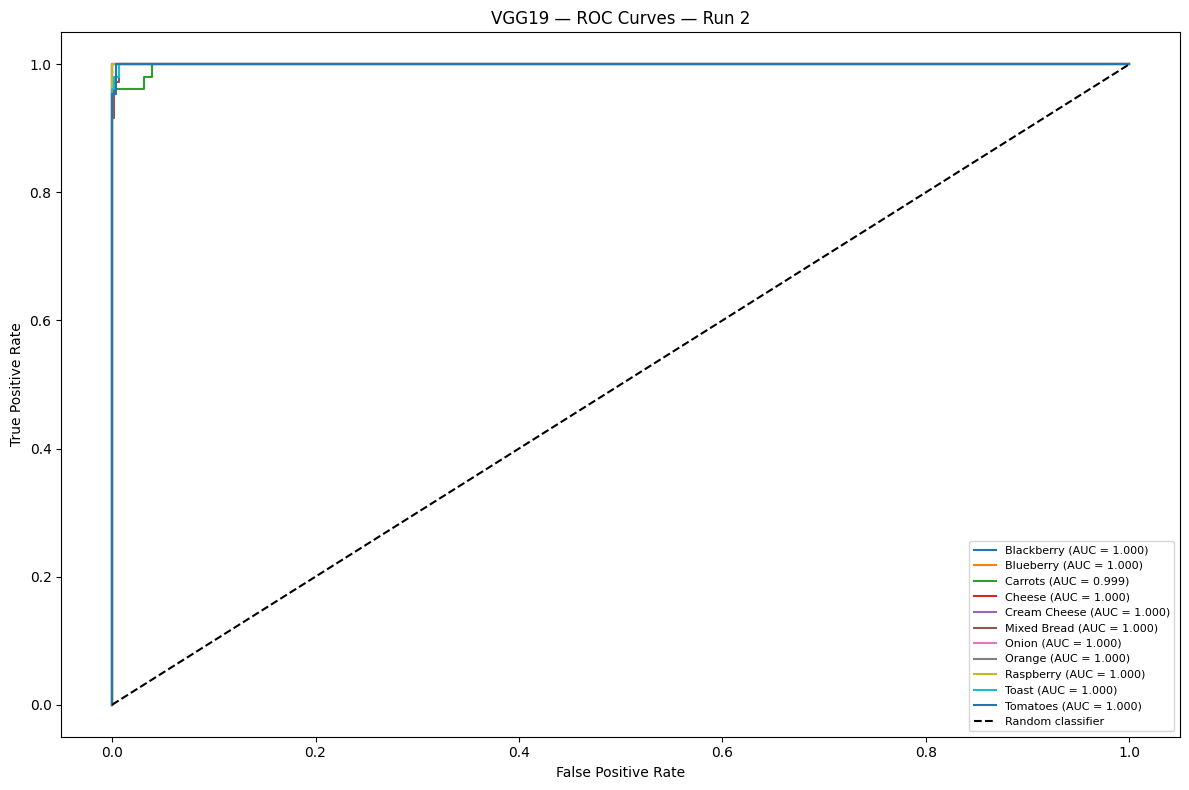

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_roc_curves_run2.png


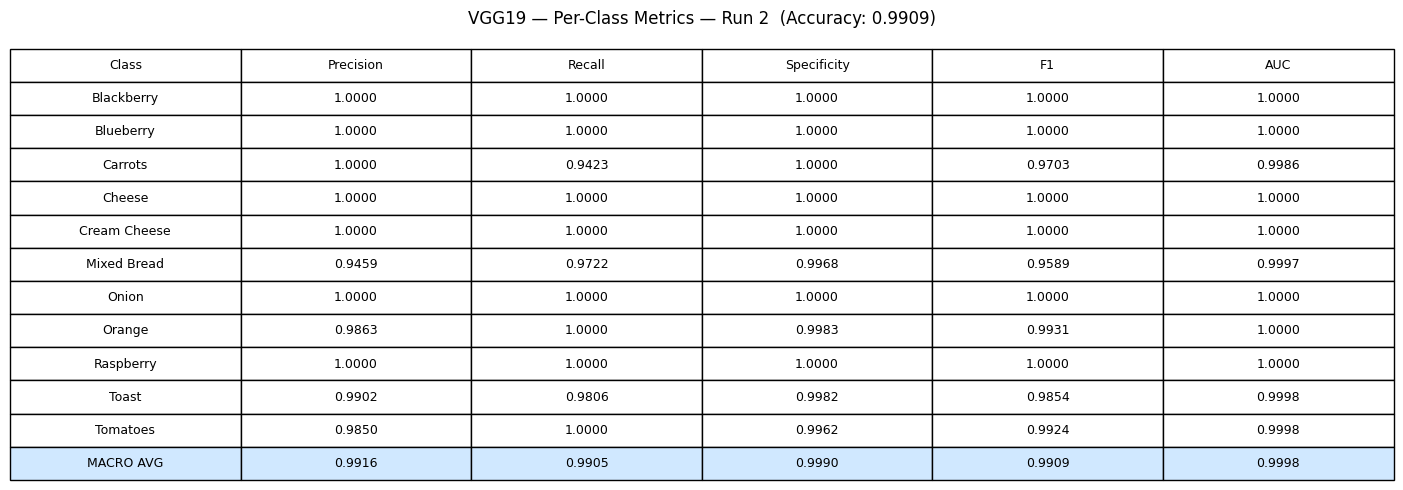

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_metrics_table_run2.png


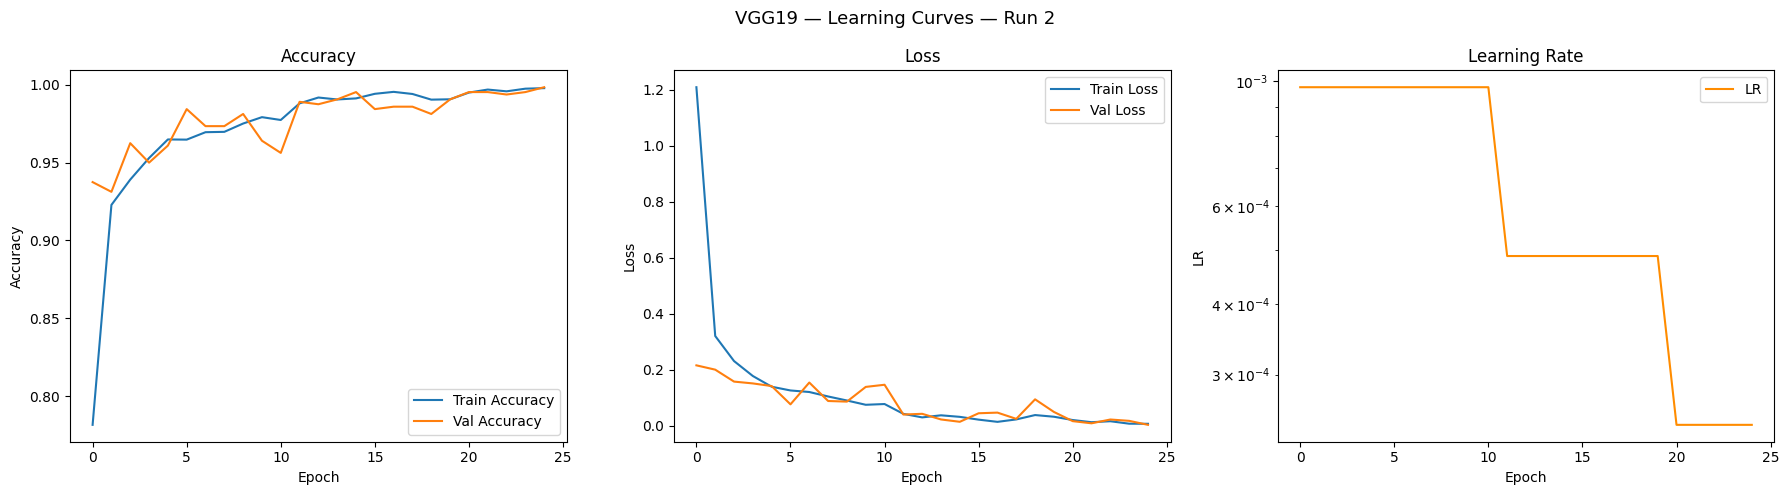

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_learning_curves_run2.png

  Evaluating VGG19 Run 3 / 5
  Checkpoint : D:\Mold Studies\Models\vgg19_run3_best.keras
21/21 [==============================] - 27s 1s/step

  Architecture : VGG19
  Run          : 3
  Accuracy     : 0.9878
  Precision    : 0.9851
  Recall       : 0.9843
  Specificity  : 0.9988
  F1 Score     : 0.9841
  Mean AUC     : 0.9997


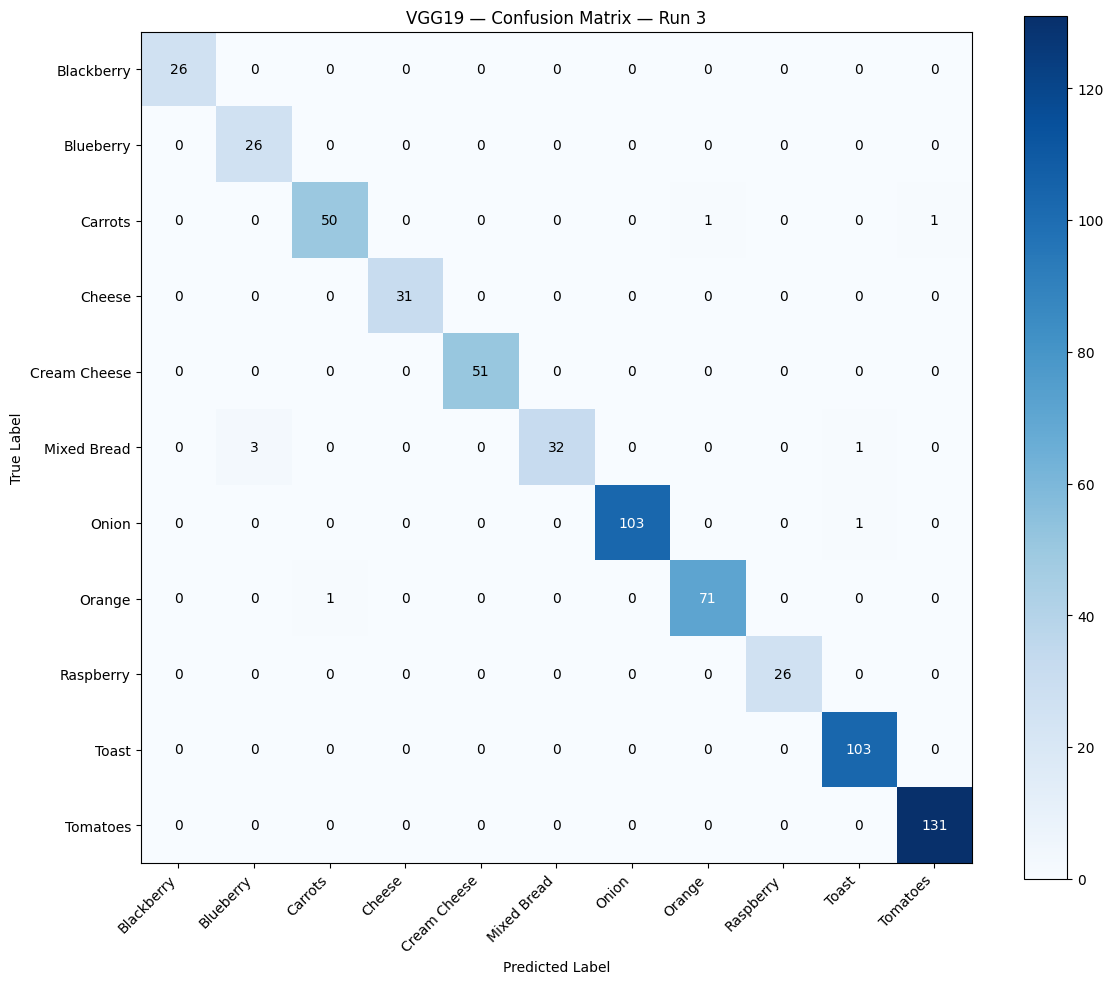

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_confusion_matrix_run3.png


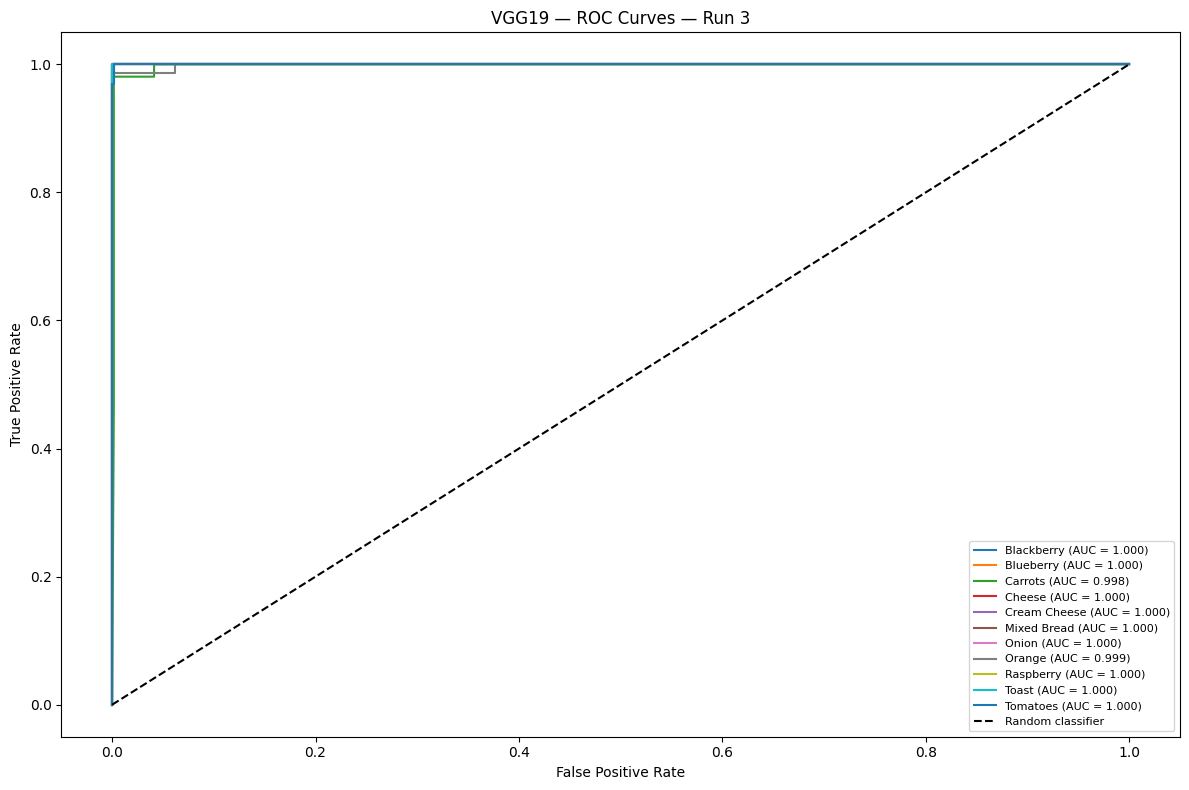

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_roc_curves_run3.png


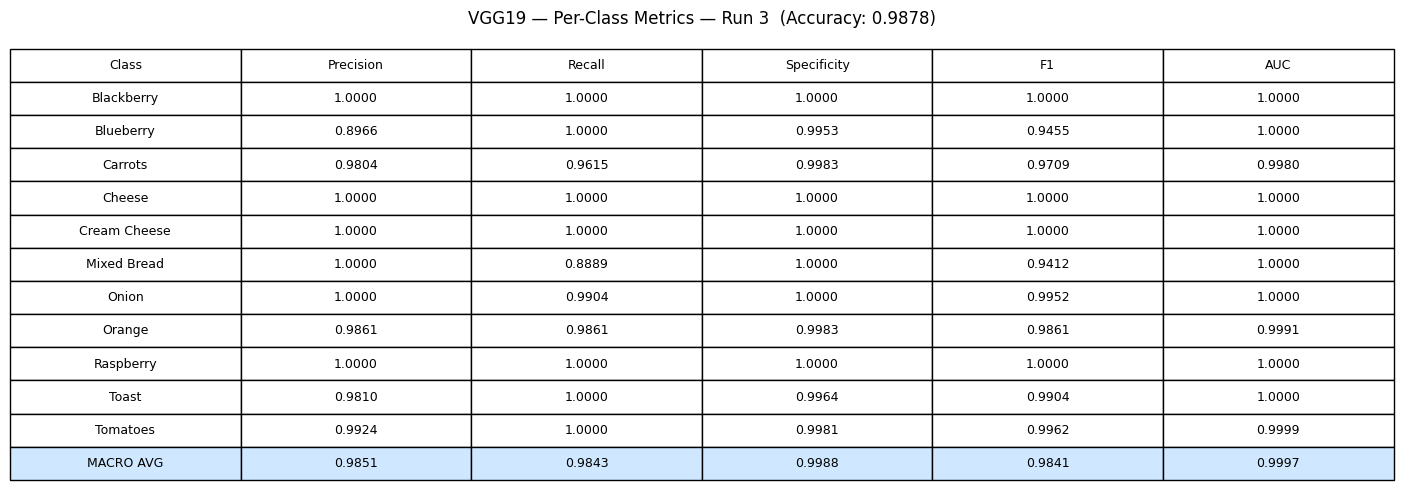

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_metrics_table_run3.png


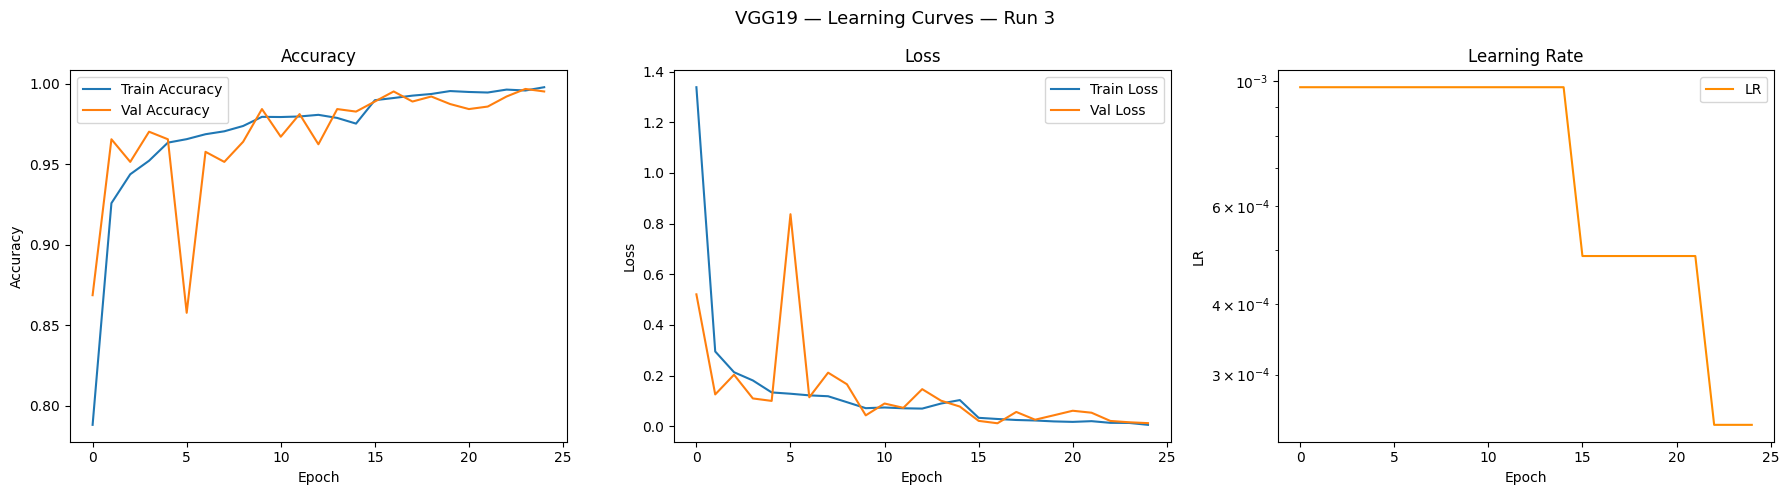

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_learning_curves_run3.png

  Evaluating VGG19 Run 4 / 5
  Checkpoint : D:\Mold Studies\Models\vgg19_run4_best.keras
21/21 [==============================] - 33s 2s/step

  Architecture : VGG19
  Run          : 4
  Accuracy     : 0.9787
  Precision    : 0.9767
  Recall       : 0.9753
  Specificity  : 0.9978
  F1 Score     : 0.9758
  Mean AUC     : 0.9992


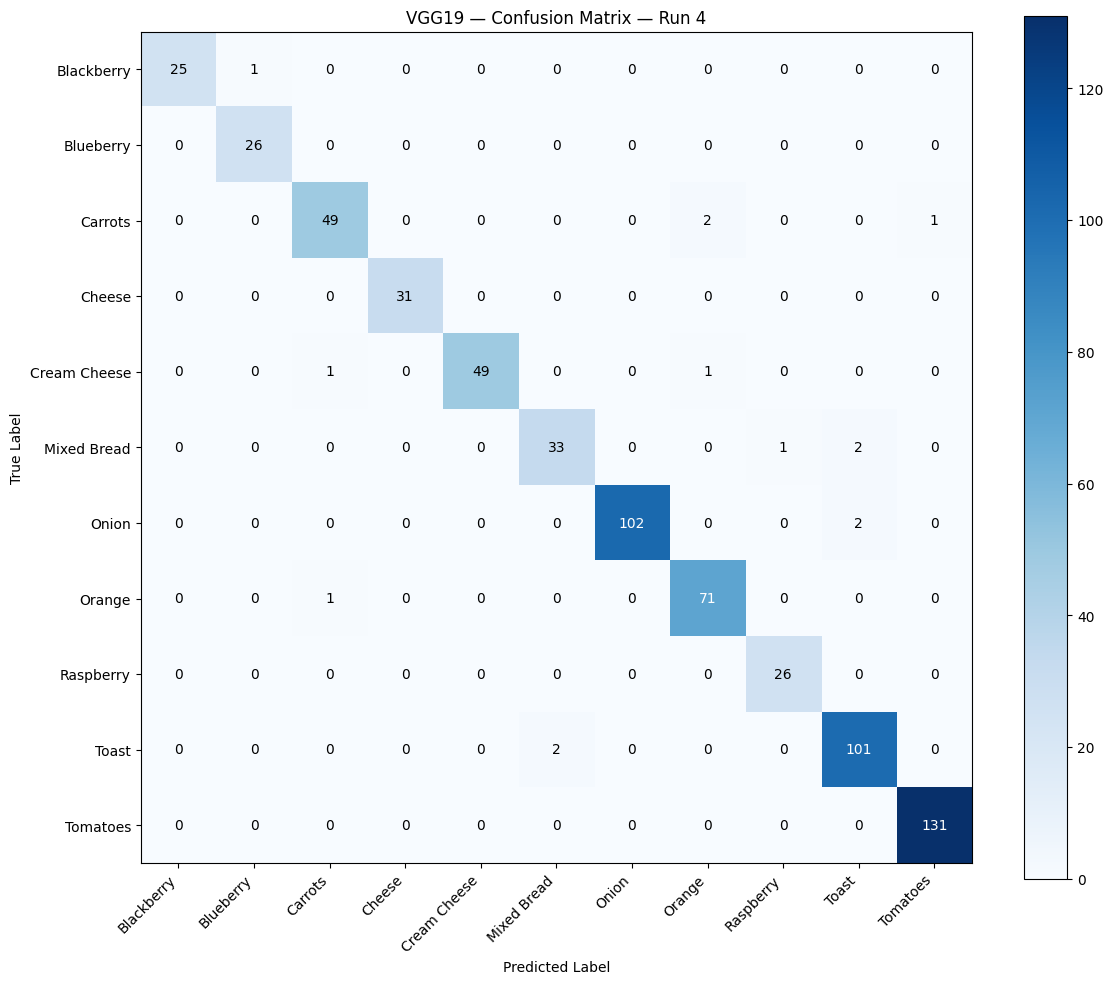

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_confusion_matrix_run4.png


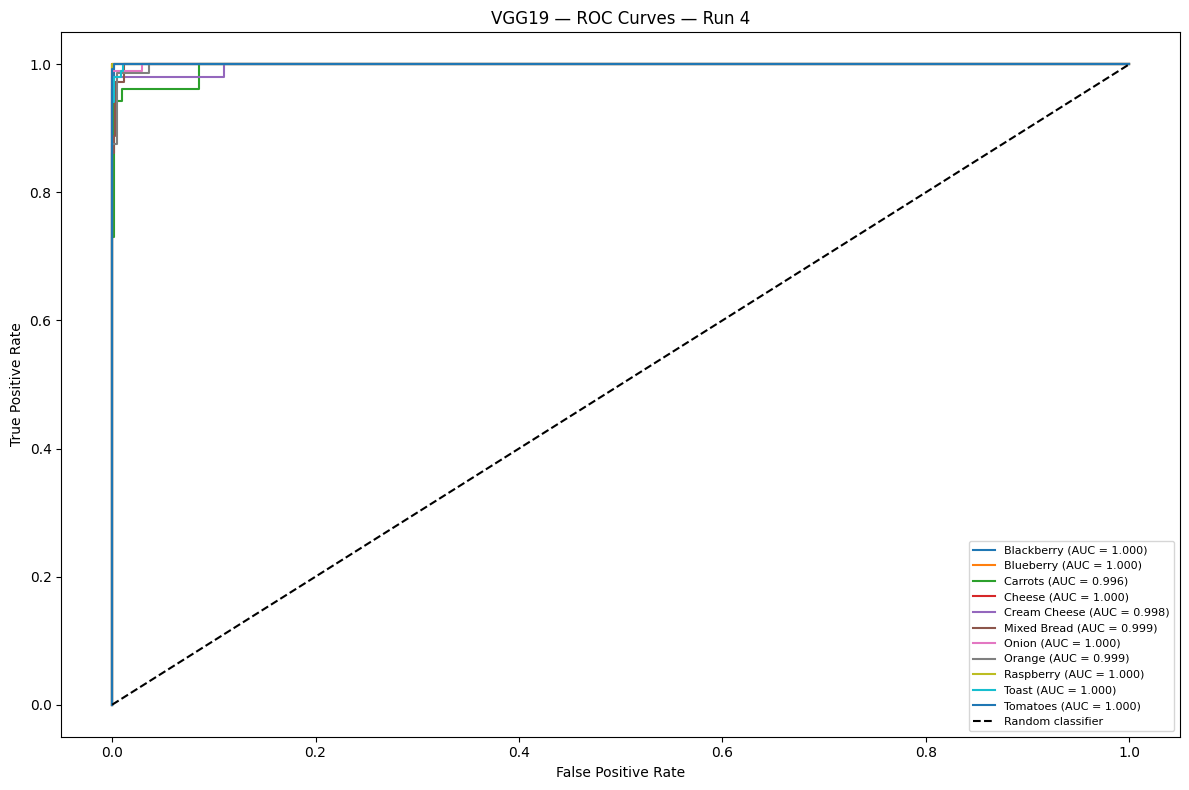

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_roc_curves_run4.png


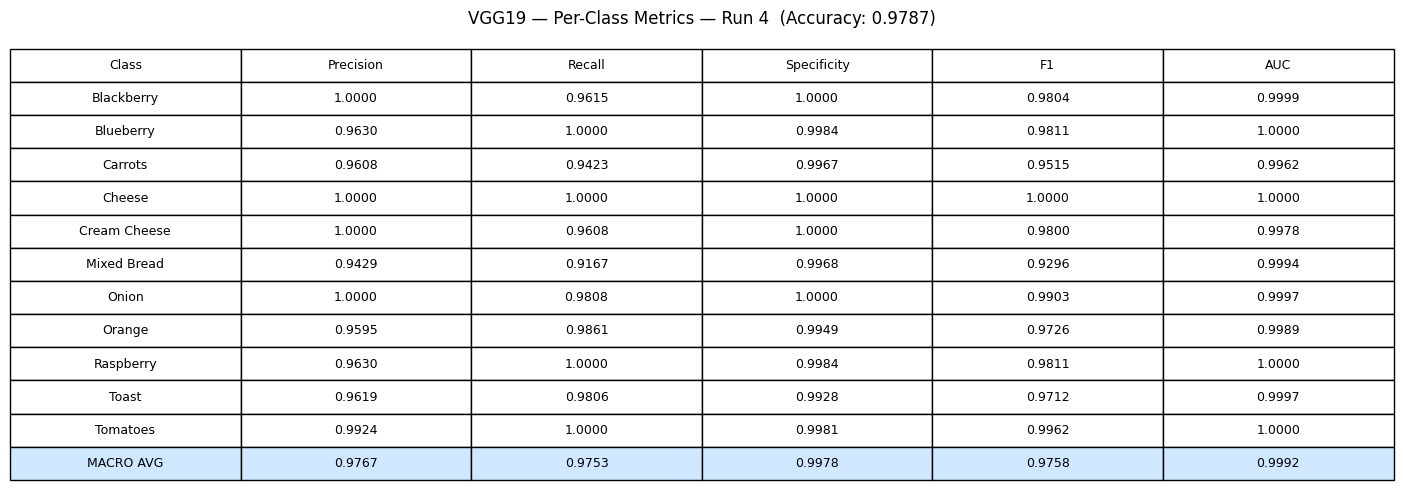

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_metrics_table_run4.png


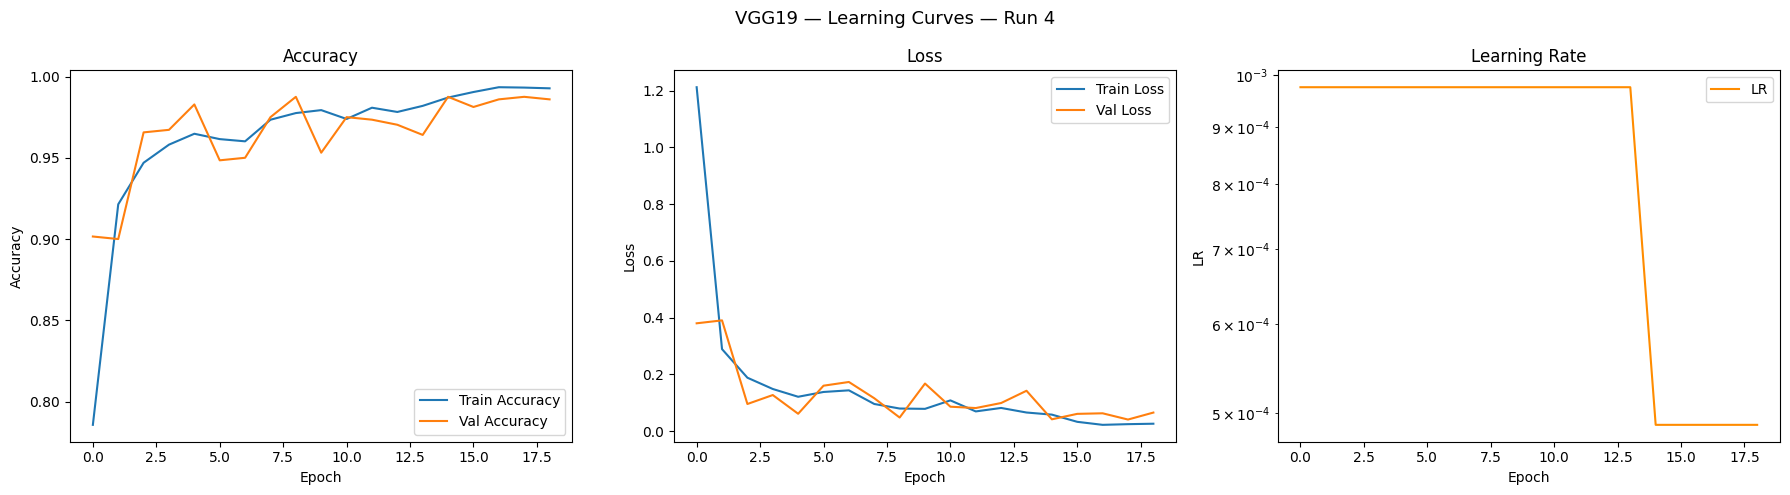

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_learning_curves_run4.png

  Evaluating VGG19 Run 5 / 5
  Checkpoint : D:\Mold Studies\Models\vgg19_run5_best.keras
21/21 [==============================] - 40s 2s/step

  Architecture : VGG19
  Run          : 5
  Accuracy     : 0.9878
  Precision    : 0.9856
  Recall       : 0.9869
  Specificity  : 0.9988
  F1 Score     : 0.9859
  Mean AUC     : 1.0000


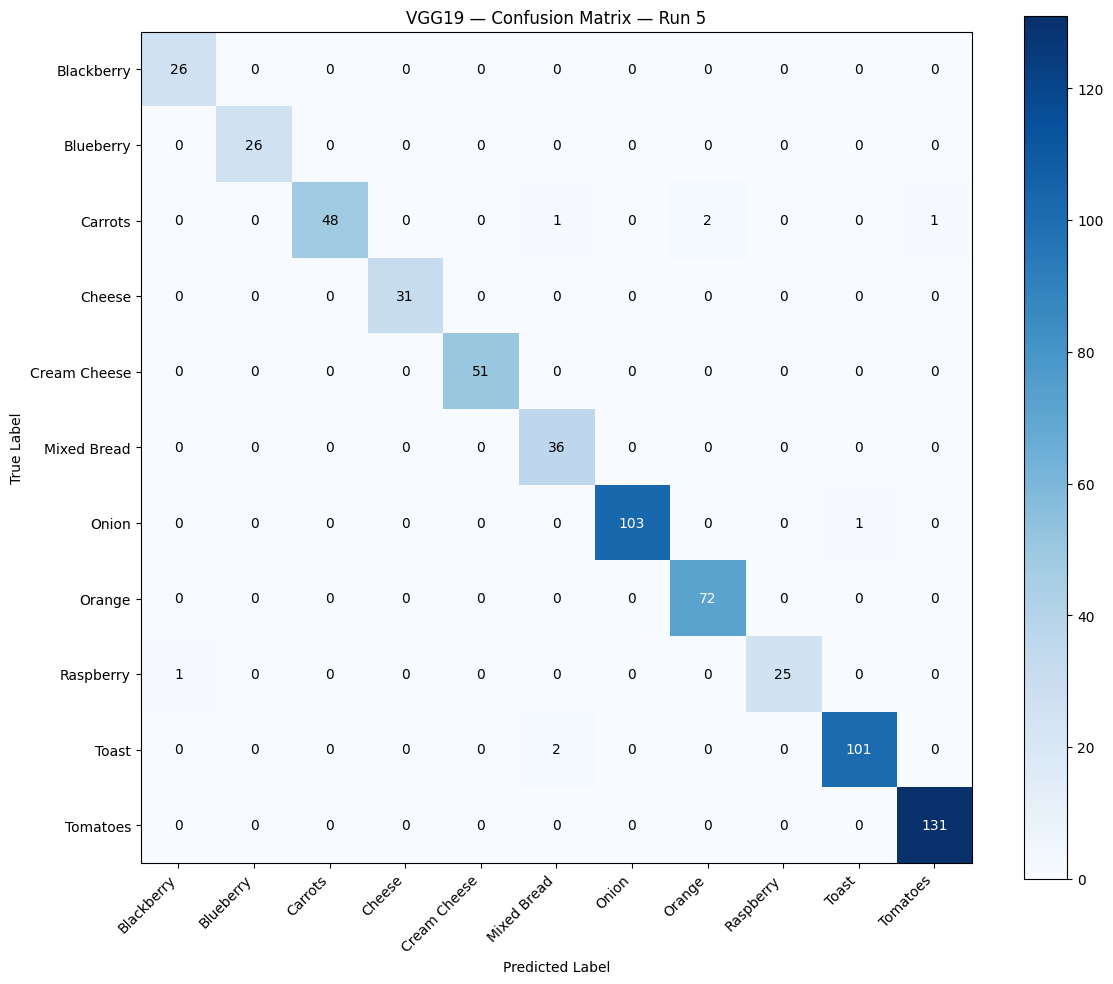

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_confusion_matrix_run5.png


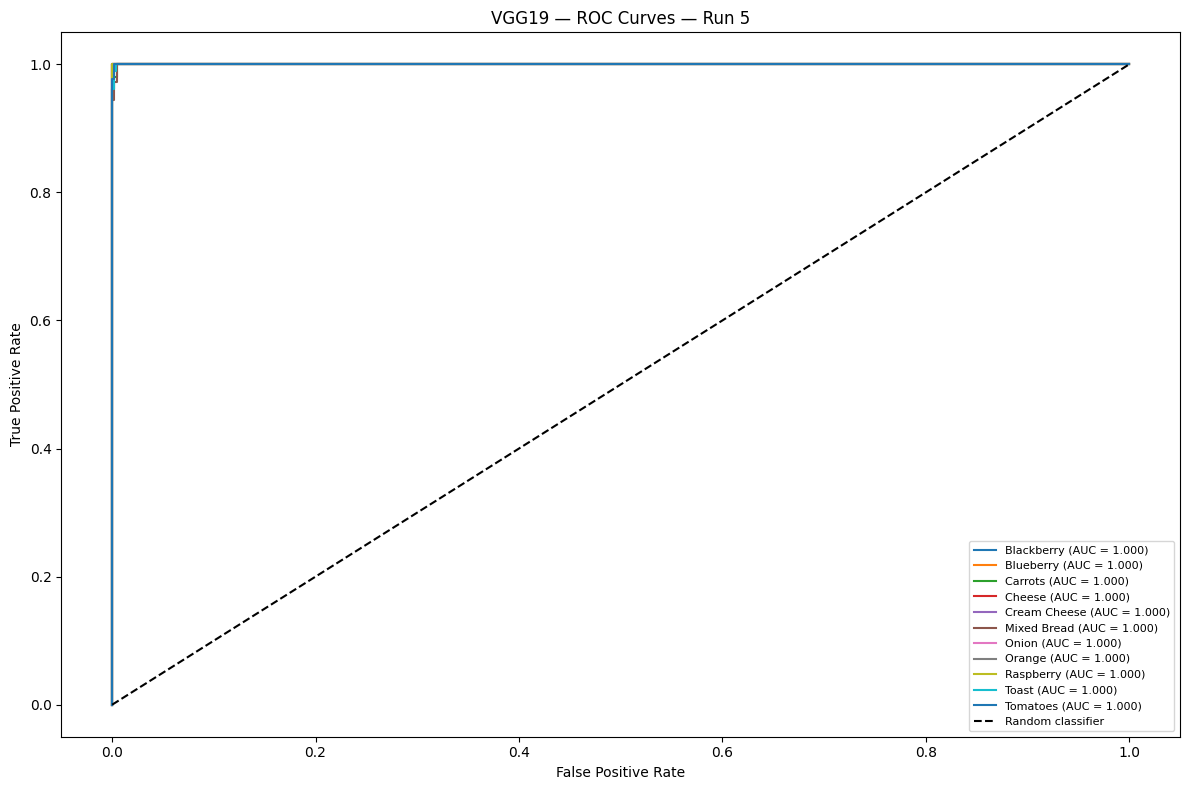

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_roc_curves_run5.png


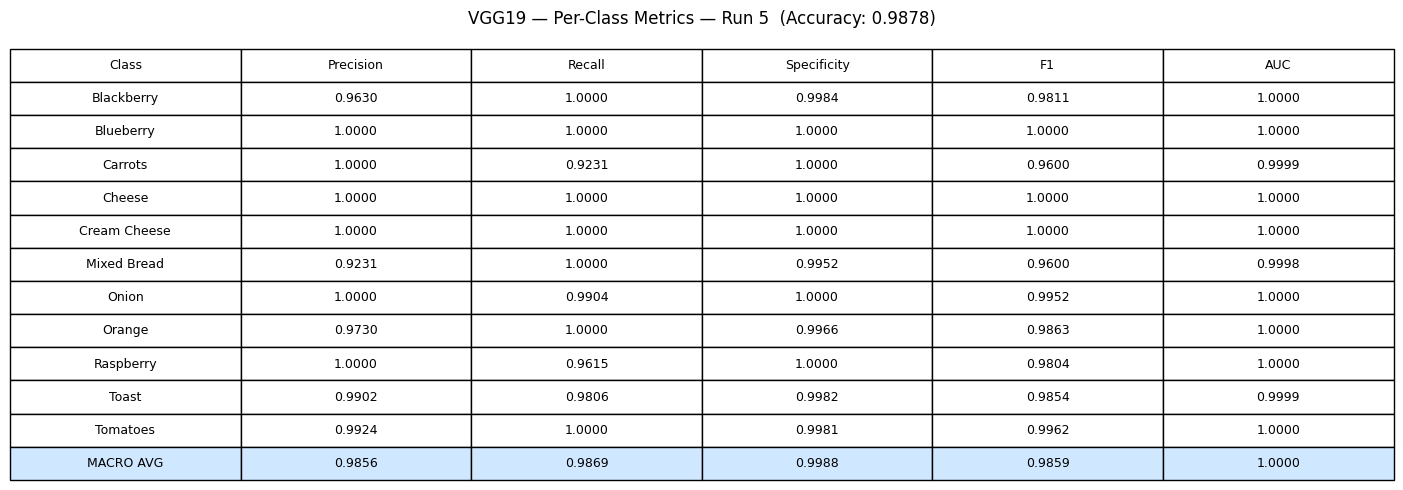

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_metrics_table_run5.png


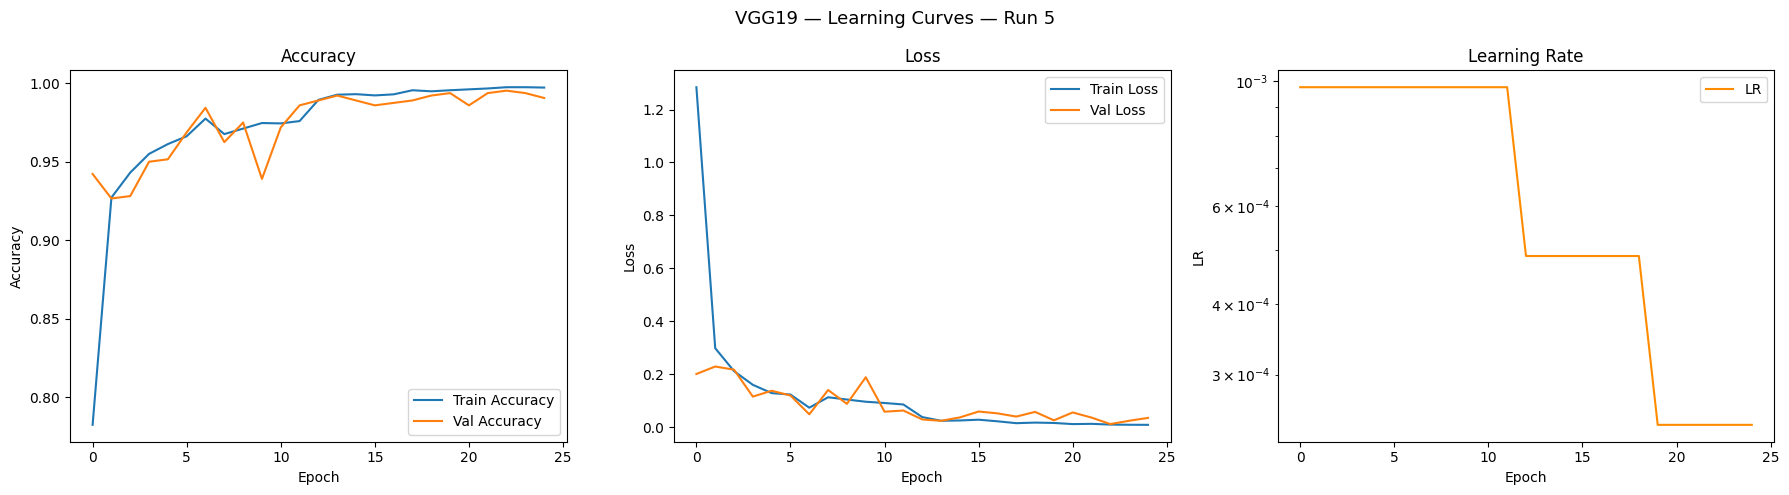

  Saved: D:\Mold Studies\Models\plots\vgg19\vgg19_learning_curves_run5.png

  STATISTICAL SUMMARY — VGG19 — All 5 Runs
  Accuracy      : mean=0.9866  std=0.0041  min=0.9787  max=0.9909
  Precision     : mean=0.9856  std=0.0050  min=0.9767  max=0.9916
  Recall        : mean=0.9847  std=0.0051  min=0.9753  max=0.9905
  Specificity   : mean=0.9986  std=0.0004  min=0.9978  max=0.9990
  F1 Score      : mean=0.9848  std=0.0050  min=0.9758  max=0.9909
  AUC           : mean=0.9997  std=0.0002  min=0.9992  max=1.0000

  Best run     : Run 2
  Accuracy     : 0.9909
  F1 Score     : 0.9909
  Mean AUC     : 0.9998

  All plots saved to : D:\Mold Studies\Models\plots\vgg19

  ✓ Fragment 4 complete.
     vgg19_all_metrics and vgg19_all_run_results
     are ready for Fragment 5 — Model Comparison.



In [6]:
"""
Fragment 4 — Evaluation & Metrics
===================================
VGG19 Mould/Fruit Multiclass Classification Pipeline

Evaluates all 5 trained runs against the test set.
Metrics computed per run and averaged across all runs:
    - Confusion Matrix
    - Accuracy
    - Precision
    - Recall
    - Specificity
    - F1 Score
    - ROC / AUC (one-vs-rest per class)
    - Learning Rate Curve

TEST DATA — loaded fresh here, never seen during training.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies\Mould Studies Multiclass"
TEST_DIR   = os.path.join(DATA_DIR, "test")
SAVE_DIR   = r"D:\Mold Studies\Models"
PLOT_DIR   = os.path.join(SAVE_DIR, "plots", "vgg19")

os.makedirs(PLOT_DIR, exist_ok=True)

# ── Step 1: Load Test Generator ───────────────────────────────────────────────

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    shuffle     = False,        # must be False for correct label alignment
)

CLASS_NAMES = list(test_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("=" * 60)
print("  Step 1 — Test Generator Ready")
print("=" * 60)
print(f"  Architecture : VGG19")
print(f"  Test samples : {test_generator.samples}")
print(f"  Classes      : {CLASS_NAMES}")
print(f"  Source       : {TEST_DIR}")
print("=" * 60)

# ── Step 2: Helper Functions ──────────────────────────────────────────────────

def compute_metrics(y_true, y_pred, y_prob):
    """
    Computes full evaluation metrics from predictions.
    Returns a dictionary of all metrics.
    """
    cm = confusion_matrix(y_true, y_pred)

    per_class = {}
    for i, cls in enumerate(CLASS_NAMES):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn

        precision   = tp / (tp + fp + 1e-7)
        recall      = tp / (tp + fn + 1e-7)
        specificity = tn / (tn + fp + 1e-7)
        f1          = 2 * precision * recall / (precision + recall + 1e-7)

        per_class[cls] = {
            "precision"  : precision,
            "recall"     : recall,
            "specificity": specificity,
            "f1"         : f1,
        }

    macro_precision   = np.mean([v["precision"]   for v in per_class.values()])
    macro_recall      = np.mean([v["recall"]      for v in per_class.values()])
    macro_specificity = np.mean([v["specificity"] for v in per_class.values()])
    macro_f1          = np.mean([v["f1"]          for v in per_class.values()])
    accuracy          = np.sum(y_true == y_pred) / len(y_true)

    # ROC / AUC — one-vs-rest per class
    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    roc_auc    = {}
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[cls] = {
            "fpr": fpr,
            "tpr": tpr,
            "auc": auc(fpr, tpr)
        }

    return {
        "cm"               : cm,
        "per_class"        : per_class,
        "accuracy"         : accuracy,
        "macro_precision"  : macro_precision,
        "macro_recall"     : macro_recall,
        "macro_specificity": macro_specificity,
        "macro_f1"         : macro_f1,
        "roc_auc"          : roc_auc,
    }


def plot_confusion_matrix(cm, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks      = np.arange(NUM_CLASSES),
        yticks      = np.arange(NUM_CLASSES),
        xticklabels = CLASS_NAMES,
        yticklabels = CLASS_NAMES,
        title       = f"VGG19 — Confusion Matrix — Run {run_idx}",
        ylabel      = "True Label",
        xlabel      = "Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    thresh = cm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    path = os.path.join(save_dir, f"vgg19_confusion_matrix_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")


def plot_roc_curves(roc_auc, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 8))

    for cls in CLASS_NAMES:
        ax.plot(
            roc_auc[cls]["fpr"],
            roc_auc[cls]["tpr"],
            label=f"{cls} (AUC = {roc_auc[cls]['auc']:.3f})"
        )

    ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
    ax.set(
        title  = f"VGG19 — ROC Curves — Run {run_idx}",
        xlabel = "False Positive Rate",
        ylabel = "True Positive Rate",
    )
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    path = os.path.join(save_dir, f"vgg19_roc_curves_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")


def plot_metrics_table(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.axis("off")

    rows = []
    for cls in CLASS_NAMES:
        pc = metrics["per_class"][cls]
        rows.append([
            cls,
            f"{pc['precision']:.4f}",
            f"{pc['recall']:.4f}",
            f"{pc['specificity']:.4f}",
            f"{pc['f1']:.4f}",
            f"{metrics['roc_auc'][cls]['auc']:.4f}",
        ])

    rows.append([
        "MACRO AVG",
        f"{metrics['macro_precision']:.4f}",
        f"{metrics['macro_recall']:.4f}",
        f"{metrics['macro_specificity']:.4f}",
        f"{metrics['macro_f1']:.4f}",
        f"{np.mean([metrics['roc_auc'][c]['auc'] for c in CLASS_NAMES]):.4f}",
    ])

    col_labels = ["Class", "Precision", "Recall",
                  "Specificity", "F1", "AUC"]

    table = ax.table(
        cellText  = rows,
        colLabels = col_labels,
        loc       = "center",
        cellLoc   = "center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.8)

    # Highlight macro row
    for j in range(len(col_labels)):
        table[len(rows), j].set_facecolor("#d0e8ff")

    ax.set_title(
        f"VGG19 — Per-Class Metrics — Run {run_idx}  "
        f"(Accuracy: {metrics['accuracy']:.4f})",
        fontsize=12, pad=20
    )

    plt.tight_layout()
    path = os.path.join(save_dir, f"vgg19_metrics_table_run{run_idx}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path}")


def plot_learning_curves(csv_path, run_idx, save_dir):
    import pandas as pd

    if not os.path.exists(csv_path):
        print(f"  ⚠️  CSV log not found for Run {run_idx}: {csv_path}")
        return

    log = pd.read_csv(csv_path)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"VGG19 — Learning Curves — Run {run_idx}", fontsize=13)

    # Accuracy
    axes[0].plot(log["epoch"], log["accuracy"],     label="Train Accuracy")
    axes[0].plot(log["epoch"], log["val_accuracy"], label="Val Accuracy")
    axes[0].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[0].legend()

    # Loss
    axes[1].plot(log["epoch"], log["loss"],     label="Train Loss")
    axes[1].plot(log["epoch"], log["val_loss"], label="Val Loss")
    axes[1].set(title="Loss", xlabel="Epoch", ylabel="Loss")
    axes[1].legend()

    # Learning Rate
    if "lr" in log.columns:
        axes[2].plot(log["epoch"], log["lr"],
                     color="darkorange", label="LR")
        axes[2].set(title="Learning Rate", xlabel="Epoch", ylabel="LR")
        axes[2].set_yscale("log")
        axes[2].legend()
    else:
        axes[2].text(0.5, 0.5, "LR not logged",
                     ha="center", va="center",
                     transform=axes[2].transAxes)
        axes[2].set_title("Learning Rate")

    plt.tight_layout()
    path = os.path.join(save_dir, f"vgg19_learning_curves_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")

# ── Step 3: Evaluate All 5 Runs ───────────────────────────────────────────────

all_metrics = []

for r in all_run_results:
    run_idx  = r["run"]
    ckpt     = os.path.join(SAVE_DIR, r["checkpoint"])
    csv_path = os.path.join(SAVE_DIR, f"vgg19_run{run_idx}_log.csv")

    print(f"\n{'='*60}")
    print(f"  Evaluating VGG19 Run {run_idx} / {TOTAL_RUNS}")
    print(f"  Checkpoint : {ckpt}")
    print(f"{'='*60}")

    # Load model
    run_model = tf.keras.models.load_model(ckpt)

    # Reset generator — must be done before every predict
    test_generator.reset()

    # Predict
    y_prob = run_model.predict(
        test_generator,
        steps   = np.ceil(test_generator.samples / BATCH_SIZE),
        verbose = 1,
    )
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_generator.classes

    # Compute metrics
    metrics        = compute_metrics(y_true, y_pred, y_prob)
    metrics["run"] = run_idx
    all_metrics.append(metrics)

    # Print run summary
    print(f"\n  Architecture : VGG19")
    print(f"  Run          : {run_idx}")
    print(f"  Accuracy     : {metrics['accuracy']:.4f}")
    print(f"  Precision    : {metrics['macro_precision']:.4f}")
    print(f"  Recall       : {metrics['macro_recall']:.4f}")
    print(f"  Specificity  : {metrics['macro_specificity']:.4f}")
    print(f"  F1 Score     : {metrics['macro_f1']:.4f}")
    print(f"  Mean AUC     : "
          f"{np.mean([metrics['roc_auc'][c]['auc'] for c in CLASS_NAMES]):.4f}")

    # Plots
    plot_confusion_matrix(metrics["cm"],    run_idx, PLOT_DIR)
    plot_roc_curves(metrics["roc_auc"],     run_idx, PLOT_DIR)
    plot_metrics_table(metrics,             run_idx, PLOT_DIR)
    plot_learning_curves(csv_path,          run_idx, PLOT_DIR)

# ── Step 4: Statistical Summary Across All 5 Runs ────────────────────────────

print(f"\n{'='*60}")
print(f"  STATISTICAL SUMMARY — VGG19 — All {TOTAL_RUNS} Runs")
print(f"{'='*60}")

metric_keys = {
    "Accuracy"   : "accuracy",
    "Precision"  : "macro_precision",
    "Recall"     : "macro_recall",
    "Specificity": "macro_specificity",
    "F1 Score"   : "macro_f1",
}

for label, key in metric_keys.items():
    vals = [m[key] for m in all_metrics]
    print(f"  {label:<14}: "
          f"mean={np.mean(vals):.4f}  "
          f"std={np.std(vals):.4f}  "
          f"min={np.min(vals):.4f}  "
          f"max={np.max(vals):.4f}")

mean_aucs = [
    np.mean([m["roc_auc"][c]["auc"] for c in CLASS_NAMES])
    for m in all_metrics
]
print(f"  {'AUC':<14}: "
      f"mean={np.mean(mean_aucs):.4f}  "
      f"std={np.std(mean_aucs):.4f}  "
      f"min={np.min(mean_aucs):.4f}  "
      f"max={np.max(mean_aucs):.4f}")

print(f"{'='*60}")

# ── Step 5: Best Run ──────────────────────────────────────────────────────────

best_metrics = max(all_metrics, key=lambda x: x["accuracy"])
print(f"\n  Best run     : Run {best_metrics['run']}")
print(f"  Accuracy     : {best_metrics['accuracy']:.4f}")
print(f"  F1 Score     : {best_metrics['macro_f1']:.4f}")
print(f"  Mean AUC     : "
      f"{np.mean([best_metrics['roc_auc'][c]['auc'] for c in CLASS_NAMES]):.4f}")

# ── Step 6: Expose for cross-model comparison ─────────────────────────────────

vgg19_all_metrics    = all_metrics
vgg19_all_run_results = all_run_results

print(f"\n  All plots saved to : {PLOT_DIR}")
print(f"\n  ✓ Fragment 4 complete.")
print(f"     vgg19_all_metrics and vgg19_all_run_results")
print(f"     are ready for Fragment 5 — Model Comparison.\n")